In [ ]:
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt


import pandas as pd
import seaborn as sns
# (npz-number, alpha)

file_numbers = [(15, .5),
                (16, 1.),
                (18, 2.),
                (14, 4.)]

suffix = '_sigma'

frames = []
N_sweeps = len(file_numbers)

for nbr, alpha in file_numbers:
    path = Path(f"data/superoperator_N4_h_sweep_{nbr}.npz")  # reused files, relabeled as sigma
    data = np.load(path)

    df = pd.DataFrame({
        "h_over_J": data["h_over_J"],
        "Delta2": data["Delta2"],
        "Delta_th": data["Delta_th"],
        "num_closer": data["num_closer"],
        "trace_distance": data["trace_distance"],
        "get_mixingtime": data["get_mixingtime"],
    })
    df["alpha"] = alpha

    frames.append(df)

ha_data = pd.concat(frames, ignore_index=True)

mix_grid = ha_data.pivot(index="h_over_J", columns="alpha", values="get_mixingtime").sort_index().sort_index(axis=1)
gap_grid = ha_data.pivot(index="h_over_J", columns="alpha", values="Delta2").sort_index().sort_index(axis=1)
tr_grid = ha_data.pivot(index="h_over_J", columns="alpha", values="trace_distance").sort_index().sort_index(axis=1)

h_vals = mix_grid.index.to_numpy()
sigma_vals = mix_grid.columns.to_numpy()
values = ["mixingtime", "Delta2", "trace_distance"]

Y = np.stack([
    mix_grid.to_numpy(),
    gap_grid.to_numpy(),
    tr_grid.to_numpy(),
], axis=1)

for alpha_idx in range(0, N_sweeps):
    x = h_vals[1:]
    y0 = Y[1:, 0, alpha_idx]
    plt.plot(x, y0, label=rf"$\alpha = {sigma_vals[alpha_idx]}$", marker=".")
    plt.legend(loc="upper center")
    plt.xlabel("h / J")
    plt.ylabel("iterations")
    plt.title(rf"Convergence to channel-fixedpoint $(\epsilon = 0.05)$")
    plt.grid(True)
    plt.savefig("docu/iterations"+suffix+".png", dpi=300, bbox_inches="tight")
plt.show()

for alpha_idx in range(0, N_sweeps):
    x = h_vals[1:]
    y0 = Y[1:, 0, alpha_idx]
    plt.semilogy(x, y0, label=rf"$\alpha = {sigma_vals[alpha_idx]}$", marker=".")
    plt.legend(loc="upper center")
    plt.xlabel("h / J")
    plt.ylabel("iterations")
    plt.title(rf"Convergence to channel-fixedpoint $(\epsilon = 0.05)$")
    plt.grid(True)
    plt.savefig("docu/iterations_log"+suffix+".png", dpi=300, bbox_inches="tight")
plt.show()

ax = sns.barplot(data=ha_data, x="h_over_J", y="Delta2", hue="alpha", dodge=True, palette="tab10")

ticks = ax.get_xticks()
labels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]

ax.set_xticks(ticks[1::2])
ax.set_xticklabels(labels[1::2])

ax.set_xlabel("h / J")
ax.set_ylabel(rf"$\Delta_2$")

ax.set_title("Spectral gap of averaged channel")
plt.legend(title=rf"$\alpha$")
ax.figure.savefig("docu/gap"+suffix+".png", dpi=300, bbox_inches="tight")

labels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]
ymin, ymax = 0., 0.15
pos=[[0,0],[0,1],[1,0],[1,1]]

fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)


for i, alpha in enumerate(ha_data["alpha"].unique()):
    ax = axs[pos[i][0], pos[i][1]]
    subset = ha_data[ha_data["alpha"] == alpha].sort_values("h_over_J")

    sns.barplot(data=subset, x="h_over_J", y="Delta2", hue="alpha", dodge=True, palette="tab10", ax=ax)

    ax.set_title(rf"$\alpha = {alpha}$")
    ax.set_xlabel("h / J")
    ax.set_ylabel(r"$\Delta_2$")
    ax.legend(title=r"$\alpha$")
    ax.set_ylim(ymin, ymax)

    ax.set_xticks(ticks[1::2])
    ax.set_xticklabels(labels[1::2])
    plt.tight_layout()
plt.show()

#ax = sns.barplot(data=ha_data, x="h_over_J", y="trace_distance", hue="alpha", dodge=True, palette="tab10")
ax = sns.lineplot(data=ha_data, x="h_over_J", y="trace_distance", hue="alpha", marker="o", palette="tab10")


ax.axhspan(0, 0.05, color="gray", alpha=0.2)

ticks = ax.get_xticks()
labels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]

#ax.set_xticks(ticks[1::2])
#ax.set_xticklabels(labels[1::2])

ax.set_xlabel("h / J")
ax.set_ylabel(rf"$\|\rho^*-\rho_{{\beta}}\|_1$")
ax.set_title("Trace distance of channel-fixedpoint to thermal state")
plt.legend(title=rf"$\alpha$")
ax.figure.savefig("docu/distance_to_gibbs"+suffix+".png", dpi=300, bbox_inches="tight")


source

ticks = ax.get_xticks()
labels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]

ax.set_xticks(ticks[1::2])
ax.set_xticklabels(labels[1::2])

ax.set_xlabel("h / J")
ax.set_ylabel(rf"$\Delta_2$")

ax.set_title("Spectral gap of averaged channel")
plt.legend(title=rf"$\alpha$")
ax.figure.savefig("docu/gap"+suffix+".png", dpi=300, bbox_inches="tight")


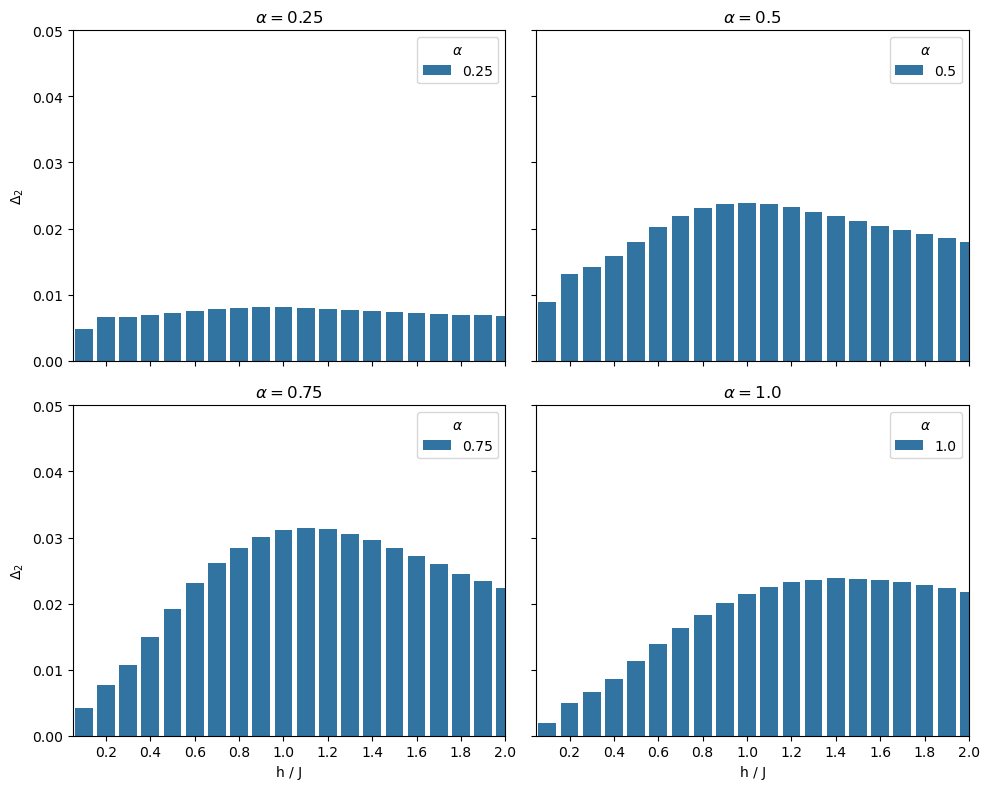

In [144]:
labels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]
ymin, ymax = 0., 0.05
pos=[[0,0],[0,1],[1,0],[1,1]]

fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)


for i, alpha in enumerate(ha_data["alpha"].unique()):
    ax = axs[pos[i][0], pos[i][1]]
    subset = ha_data[ha_data["alpha"] == alpha].sort_values("h_over_J")

    sns.barplot(data=subset, x="h_over_J", y="Delta2", hue="alpha", dodge=True, palette="tab10", ax=ax)

    ax.set_title(rf"$\alpha = {alpha}$")
    ax.set_xlabel("h / J")
    ax.set_ylabel(r"$\Delta_2$")
    ax.legend(title=r"$\alpha$")
    ax.set_ylim(ymin, ymax)

    ax.set_xticks(ticks[1::2])
    ax.set_xticklabels(labels[1::2])
    plt.tight_layout()
plt.show()

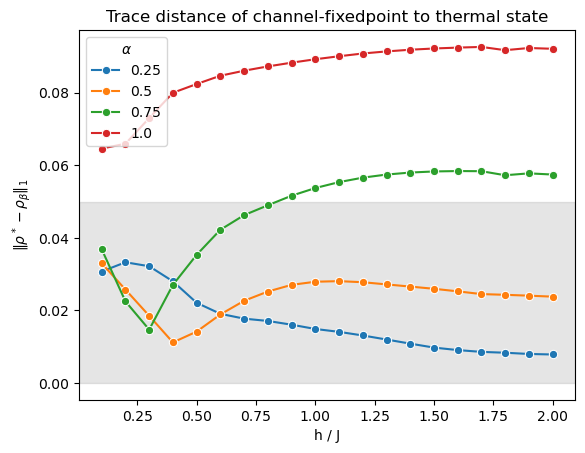

In [145]:
#ax = sns.barplot(data=ha_data, x="h_over_J", y="trace_distance", hue="alpha", dodge=True, palette="tab10")
ax = sns.lineplot(data=ha_data, x="h_over_J", y="trace_distance", hue="alpha", marker="o", palette="tab10")


ax.axhspan(0, 0.05, color="gray", alpha=0.2)

ticks = ax.get_xticks()
labels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]

#ax.set_xticks(ticks[1::2])
#ax.set_xticklabels(labels[1::2])

ax.set_xlabel("h / J")
ax.set_ylabel(rf"$\|\rho^*-\rho_{{\beta}}\|_1$")
ax.set_title("Trace distance of channel-fixedpoint to thermal state")
plt.legend(title=rf"$\alpha$")
ax.figure.savefig("docu/distance_to_gibbs"+suffix+".png", dpi=300, bbox_inches="tight")



## Superoperator analysis from .npz files for sigma

In [ ]:
path = Path(f"data/superoperator_N4_h_sweep_12.npz")  # reused files, relabeled as sigma
data = np.load(path)

coarse_hs = np.linspace(0.2,2.0,10)
df = df[df["h_over_J"].round(10).isin(np.round(coarse_hs, 10))]

np.savez_compressed(
    "data/superoperator_N4_h_sweep_18.npz",
    **{col: df[col].to_numpy() for col in df.columns}
)

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 1 to 19
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   h_over_J        10 non-null     float64
 1   Delta2          10 non-null     float64
 2   Delta_th        10 non-null     float64
 3   num_closer      10 non-null     int64  
 4   trace_distance  10 non-null     float64
 5   get_mixingtime  10 non-null     float64
 6   sigma           10 non-null     float64
dtypes: float64(6), int64(1)
memory usage: 692.0 bytes


In [ ]:
# (npz-number, alpha)

file_numbers = [(15, .5),
                (16, 1.),
                (18, 2.),
                (14, 4.)]

suffix = '_sigma'

frames = []
N_sweeps = len(file_numbers)

for nbr, alpha in file_numbers:
    path = Path(f"data/superoperator_N4_h_sweep_{nbr}.npz")  # reused files, relabeled as sigma
    data = np.load(path)

    df = pd.DataFrame({
        "h_over_J": data["h_over_J"],
        "Delta2": data["Delta2"],
        "Delta_th": data["Delta_th"],
        "num_closer": data["num_closer"],
        "trace_distance": data["trace_distance"],
        "get_mixingtime": data["get_mixingtime"],
    })
    df["alpha"] = alpha
    frames.append(df)

ha_data = pd.concat(frames, ignore_index=True)

mix_grid = ha_data.pivot(index="h_over_J", columns="alpha", values="get_mixingtime").sort_index().sort_index(axis=1)
gap_grid = ha_data.pivot(index="h_over_J", columns="alpha", values="Delta2").sort_index().sort_index(axis=1)
tr_grid = ha_data.pivot(index="h_over_J", columns="alpha", values="trace_distance").sort_index().sort_index(axis=1)

h_vals = mix_grid.index.to_numpy()
sigma_vals = mix_grid.columns.to_numpy()
values = ["mixingtime", "Delta2", "trace_distance"]

Y = np.stack([
    mix_grid.to_numpy(),
    gap_grid.to_numpy(),
    tr_grid.to_numpy(),
], axis=1)

for alpha_idx in range(0, N_sweeps):
    x = h_vals[:]
    y0 = Y[1:, 0, alpha_idx]
    plt.plot(x, y0, label=rf"$\alpha = {sigma_vals[alpha_idx]}$", marker=".")
    plt.legend(loc="upper center")
    plt.xlabel("h / J")
    plt.ylabel("iterations")
    plt.title(rf"Convergence to channel-fixedpoint $(\epsilon = 0.05)$")
    plt.grid(True)
    plt.savefig("docu/iterations"+suffix+".png", dpi=300, bbox_inches="tight")
plt.show()

for alpha_idx in range(0, N_sweeps):
    x = h_vals[1:]
    y0 = Y[1:, 0, alpha_idx]
    plt.semilogy(x, y0, label=rf"$\alpha = {sigma_vals[alpha_idx]}$", marker=".")
    plt.legend(loc="upper center")
    plt.xlabel("h / J")
    plt.ylabel("iterations")
    plt.title(rf"Convergence to channel-fixedpoint $(\epsilon = 0.05)$")
    plt.grid(True)
    plt.savefig("docu/iterations_log"+suffix+".png", dpi=300, bbox_inches="tight")
plt.show()
    

ax = sns.barplot(data=ha_data, x="h_over_J", y="Delta2", hue="alpha", dodge=True, palette="tab10")

ticks = ax.get_xticks()
labels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]

ax.set_xticks(ticks[1::2])
ax.set_xticklabels(labels[1::2])

ax.set_xlabel("h / J")
ax.set_ylabel(rf"$\Delta_2$")

ax.set_title("Spectral gap of averaged channel")
plt.legend(title=rf"$\alpha$")
ax.figure.savefig("docu/gap"+suffix+".png", dpi=300, bbox_inches="tight")

labels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]
ymin, ymax = 0., 0.15
pos=[[0,0],[0,1],[1,0],[1,1]]

fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)


for i, alpha in enumerate(ha_data["alpha"].unique()):
    ax = axs[pos[i][0], pos[i][1]]
    subset = ha_data[ha_data["alpha"] == alpha].sort_values("h_over_J")

    sns.barplot(data=subset, x="h_over_J", y="Delta2", hue="alpha", dodge=True, palette="tab10", ax=ax)

    ax.set_title(rf"$\alpha = {alpha}$")
    ax.set_xlabel("h / J")
    ax.set_ylabel(r"$\Delta_2$")
    ax.legend(title=r"$\alpha$")
    ax.set_ylim(ymin, ymax)

    ax.set_xticks(ticks[1::2])
    ax.set_xticklabels(labels[1::2])
    plt.tight_layout()
plt.show()

#ax = sns.barplot(data=ha_data, x="h_over_J", y="trace_distance", hue="alpha", dodge=True, palette="tab10")
ax = sns.lineplot(data=ha_data, x="h_over_J", y="trace_distance", hue="alpha", marker="o", palette="tab10")


ax.axhspan(0, 0.05, color="gray", alpha=0.2)

ticks = ax.get_xticks()
labels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]

#ax.set_xticks(ticks[1::2])
#ax.set_xticklabels(labels[1::2])

ax.set_xlabel("h / J")
ax.set_ylabel(rf"$\|\rho^*-\rho_{{\beta}}\|_1$")
ax.set_title("Trace distance of channel-fixedpoint to thermal state")
plt.legend(title=rf"$\alpha$")
ax.figure.savefig("docu/distance_to_gibbs"+suffix+".png", dpi=300, bbox_inches="tight")

